# Cease & Desist Document Processing System
## Multi-Agent AI Pipeline · LangChain + LangGraph + Groq + LangSmith + Arize

---

### Project Overview
An enterprise-grade intelligent document processing system that:
1. **Loads** scanned PDF documents
2. **Classifies** them into `Cease`, `Uncertain`, or `Irrelevant`
3. **Routes** each document to the correct downstream agent
4. **Audits** every action for compliance
5. **Traces** every LLM call via LangSmith
6. **Monitors** model behaviour and data quality via Arize Phoenix

### Architecture
```
PDF Document
     |
     v
[Document Loader Agent]   -- extracts raw text
     |
     v
[Classification Agent]    -- Groq LLM + confidence gate
     |
 ____|____________________
|            |            |
v            v            v
Cease    Irrelevant   Uncertain
|            |            |
v            v            v
[Database] [Archive]  [HITL Agent]
Agent      Agent      human review
|            |            |
|____________|____________|
             |
             v
        [Audit Agent]     -- logs every step
             |
      LangSmith trace + Arize monitor
```

### Tech Stack
| Layer | Technology |
|-------|-----------|
| LLM | Groq — llama-3.3-70b-versatile |
| Orchestration | LangGraph StateGraph |
| LLM Tracing | LangSmith |
| Observability | Arize Phoenix |
| Embeddings | HuggingFace sentence-transformers (local, free) |
| PDF extraction | pypdf |
| Database | SQLite |
| Archiving | JSONL flat file |
| Vector search | FAISS |
| State checkpoints | LangGraph MemorySaver |


## Section 1 · Installation

Run once per Colab session. Installs all required packages.

 The full stack runs on:
- `langchain-groq` for the LLM
- `arize-phoenix` + `opentelemetry` for observability
- `sentence-transformers` for free local embeddings


In [97]:
%pip install -q \
    langchain \
    langchain-groq \
    langchain-community \
    langgraph \
    pypdf \
    reportlab \
    faiss-cpu \
    sentence-transformers \
    tiktoken \
    pydantic \
    arize-phoenix \
    arize-phoenix-otel \
    opentelemetry-sdk \
    opentelemetry-exporter-otlp \
    openinference-instrumentation-langchain \
    --upgrade -q

print("All packages installed successfully.")


All packages installed successfully.


## Section 2 · Configuration & API Keys

### Keys Used in This Project

| Key | Purpose | Where to get it |
|-----|---------|----------------|
| `GROQ_API_KEY` | LLM inference | console.groq.com (free) |
| `LANGSMITH_API_KEY` | LLM call tracing | smith.langchain.com (free) |
| `ARIZE_API_KEY` | Model observability | app.arize.com (free) |
| `ARIZE_SPACE_ID` | Arize workspace ID | app.arize.com → Settings |

### How to add keys in Colab
1. Click the **key icon** in the left sidebar (Secrets)
2. Add each key with the exact names above
3. Run this cell — keys are loaded automatically, no hardcoding needed




In [98]:
import os
import sys
from pathlib import Path

# ─── Key Loader ──────────────────────────────────────────────────────────────
def load_key(colab_secret_name: str, env_var_name: str, prompt_label: str) -> str:
    """
    Load a secret key in priority order:
      1. Colab Secrets (userdata) -- preferred, never hardcoded
      2. Environment variable     -- works in non-Colab environments
      3. Manual input prompt      -- fallback for first-time setup
    """
    # Try Colab Secrets
    try:
        from google.colab import userdata          # Colab system import only
        val = userdata.get(colab_secret_name)
        if val and val.strip():
            print(f"  {prompt_label}: loaded from Colab Secrets")
            return val.strip()
    except Exception:
        pass

    # Try environment variable
    val = os.environ.get(env_var_name, "").strip()
    if val:
        print(f"  {prompt_label}: loaded from environment variable")
        return val

    # Manual input fallback
    val = input(f"  Enter {prompt_label}: ").strip()
    return val

print("Loading API keys...")

GROQ_API_KEY    = load_key("GROQ_API_KEY",    "GROQ_API_KEY",    "Groq API Key")
LANGSMITH_KEY   = load_key("LANGSMITH_API_KEY","LANGSMITH_API_KEY","LangSmith API Key")
ARIZE_API_KEY   = load_key("ARIZE_API_KEY",   "ARIZE_API_KEY",   "Arize API Key")
ARIZE_SPACE_ID  = load_key("ARIZE_SPACE_ID",  "ARIZE_SPACE_ID",  "Arize Space ID")

# Set env vars for LangChain/LangSmith internals
os.environ["GROQ_API_KEY"]          = GROQ_API_KEY
os.environ["LANGCHAIN_API_KEY"]     = LANGSMITH_KEY
os.environ["LANGCHAIN_TRACING_V2"]  = "true" if LANGSMITH_KEY else "false"
os.environ["LANGCHAIN_PROJECT"]     = "cease-desist-multiagent"
os.environ["LANGCHAIN_ENDPOINT"]    = "https://api.smith.langchain.com"

# ─── Validate ────────────────────────────────────────────────────────────────
print()
print(f"  Groq API Key    : {'SET' if GROQ_API_KEY    else 'MISSING -- LLM will fail'}")
print(f"  LangSmith Key   : {'SET -- tracing ON' if LANGSMITH_KEY  else 'not set -- tracing OFF'}")
print(f"  Arize API Key   : {'SET' if ARIZE_API_KEY   else 'not set -- Arize disabled'}")
print(f"  Arize Space ID  : {'SET' if ARIZE_SPACE_ID  else 'not set -- Arize disabled'}")

# ─── File Paths (Colab) ───────────────────────────────────────────────────────
# Running in Google Colab -- use /content/ filesystem
BASE_DIR       = Path("/content")
PDF_DIR        = BASE_DIR / "Sample Docs"
OUTPUT_DIR     = BASE_DIR / "outputs"
DB_PATH        = OUTPUT_DIR / "cease_desist.db"
ARCHIVE_PATH   = OUTPUT_DIR / "archive.jsonl"
AUDIT_LOG_PATH = OUTPUT_DIR / "audit.log"
FAISS_INDEX    = OUTPUT_DIR / "faiss_index"

# Create directories
PDF_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ─── Model & Threshold Config ────────────────────────────────────────────────
GROQ_MODEL           = "llama-3.3-70b-versatile"
TEMPERATURE          = 0.0
MAX_TOKENS           = 512
CONFIDENCE_THRESHOLD = 0.70   # Below this -> Uncertain -> HITL
MAX_LLM_RETRIES      = 3
MAX_HITL_RETRIES     = 3

print()
print(f"  Base dir   : {BASE_DIR}")
print(f"  PDF dir    : {PDF_DIR}")
print(f"  Output dir : {OUTPUT_DIR}")
print(f"  Database   : {DB_PATH}")
print(f"  Archive    : {ARCHIVE_PATH}")
print(f"  Audit log  : {AUDIT_LOG_PATH}")
print(f"  FAISS idx  : {FAISS_INDEX}")
print(f"  LLM model  : Groq / {GROQ_MODEL}")


Loading API keys...
  Groq API Key: loaded from Colab Secrets
  LangSmith API Key: loaded from Colab Secrets
  Arize API Key: loaded from Colab Secrets
  Arize Space ID: loaded from Colab Secrets

  Groq API Key    : SET
  LangSmith Key   : SET -- tracing ON
  Arize API Key   : SET
  Arize Space ID  : SET

  Base dir   : /content
  PDF dir    : /content/Sample Docs
  Output dir : /content/outputs
  Database   : /content/outputs/cease_desist.db
  Archive    : /content/outputs/archive.jsonl
  Audit log  : /content/outputs/audit.log
  FAISS idx  : /content/outputs/faiss_index
  LLM model  : Groq / llama-3.3-70b-versatile


## Section 2.5 · Upload PDFs to Colab

Upload all your PDF documents. The file picker will open — select all your PDFs at once.
They will be stored in `/content/Sample Docs/` for processing.


In [99]:
from google.colab import files
import shutil

print("Upload your PDF files (select all 19 PDFs at once)...")
print("Click the upload button below:")

uploaded = files.upload()

# Move uploaded files to PDF_DIR
for filename in uploaded.keys():
    src = f"/content/{filename}"
    dst = PDF_DIR / filename
    shutil.move(src, str(dst))
    print(f"  ✓ Moved: {filename}")

print(f"\nUploaded {len(uploaded)} PDF(s) to {PDF_DIR}")


Upload your PDF files (select all 19 PDFs at once)...
Click the upload button below:


Saving notice_5.pdf to notice_5.pdf
Saving LOA5.pdf to LOA5.pdf
  ✓ Moved: notice_5.pdf
  ✓ Moved: LOA5.pdf

Uploaded 2 PDF(s) to /content/Sample Docs


## Section 3 · Arize Phoenix Setup

**Arize Phoenix** provides production-grade LLM observability:
- Traces every LLM call with inputs, outputs, latency, token counts
- Tracks classification drift over time
- Alerts on anomalies (low confidence, high retry rates)
- Works alongside LangSmith (LangSmith = developer tracing, Arize = production monitoring)

This cell initialises the OpenTelemetry exporter pointing at your Arize workspace.


In [100]:
ARIZE_ENABLED = False

if ARIZE_API_KEY and ARIZE_SPACE_ID:
    try:
        from opentelemetry import trace as otel_trace
        from opentelemetry.sdk.trace import TracerProvider
        from opentelemetry.sdk.trace.export import BatchSpanProcessor
        from opentelemetry.sdk.resources import Resource
        from opentelemetry.exporter.otlp.proto.grpc.trace_exporter import OTLPSpanExporter
        from openinference.instrumentation.langchain import LangChainInstrumentor

        # Suppress verbose OpenTelemetry exporter error logs (non-fatal)
        import logging as otel_logging
        otel_logging.getLogger("opentelemetry.exporter.otlp.proto.grpc.exporter").setLevel(otel_logging.CRITICAL)

        # Check if tracer provider is already set (avoid re-initialization warnings)
        existing_provider = otel_trace.get_tracer_provider()
        is_already_set = not isinstance(existing_provider, type(TracerProvider())) or \
                        existing_provider.__class__.__name__ == 'ProxyTracerProvider'

        if is_already_set:
            # Tracer already initialized, just verify Arize is enabled
            ARIZE_ENABLED = True
            print("Arize Phoenix observability: ENABLED (already initialized)")
            print(f"  Project  : arize-lab-demo")
            print(f"  Model ID : cease-desist-classifier")
        else:
            # First time initialization
            # Create resource with required Arize attributes
            # Using existing project: arize-lab-demo
            resource = Resource.create({
                "model_id": "cease-desist-classifier",
                "arize.project.name": "arize-lab-demo",
                "service.name": "cease-desist-classifier",
            })

            # Build OTLP exporter pointing at Arize Phoenix cloud
            arize_exporter = OTLPSpanExporter(
                endpoint="https://otlp.arize.com/v1",
                headers={
                    "api_key":  ARIZE_API_KEY,
                    "space_id": ARIZE_SPACE_ID,
                },
                insecure=False,
                timeout=30,
            )

            tracer_provider = TracerProvider(resource=resource)
            batch_processor = BatchSpanProcessor(arize_exporter, max_queue_size=2048)
            tracer_provider.add_span_processor(batch_processor)
            otel_trace.set_tracer_provider(tracer_provider)

            # Auto-instrument all LangChain / LangGraph calls
            LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

            ARIZE_ENABLED = True
            print("Arize Phoenix observability: ENABLED")
            print(f"  Space ID : {ARIZE_SPACE_ID[:8]}...")
            print(f"  Project  : arize-lab-demo")
            print(f"  Model ID : cease-desist-classifier")
            print("  Dashboard: https://app.arize.com")
            print("  Note: Traces may take 10-30s to appear (batching)")

    except Exception as e:
        print(f"Arize setup failed (non-fatal): {e}")
        import traceback
        traceback.print_exc()
        print("  Continuing without Arize observability.")
else:
    print("Arize keys not set -- observability disabled.")
    print("  Add ARIZE_API_KEY and ARIZE_SPACE_ID to Colab Secrets to enable.")

Arize Phoenix observability: ENABLED
  Space ID : U3BhY2U6...
  Project  : arize-lab-demo
  Model ID : cease-desist-classifier
  Dashboard: https://app.arize.com
  Note: Traces may take 10-30s to appear (batching)


## Section 4 · Imports

All imports in one place.


In [101]:
# Standard library
import json
import logging
import sqlite3
import datetime
import uuid
from enum import Enum
from typing import Optional, List, TypedDict

# Third-party
from pydantic import BaseModel, Field
from pypdf import PdfReader

# LangChain core
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, SystemMessage

# ─── LLM: Groq only ──────────────────────────────────────────────────────────
from langchain_groq import ChatGroq

llm = ChatGroq(
    model=GROQ_MODEL,
    temperature=TEMPERATURE,
    max_tokens=MAX_TOKENS,
    groq_api_key=GROQ_API_KEY,
)

# ─── LangGraph ────────────────────────────────────────────────────────────────
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

print(f"Groq LLM ready      : {GROQ_MODEL}")
print(f"LangSmith tracing   : {os.environ.get('LANGCHAIN_TRACING_V2', 'false')}")
print(f"Arize observability : {'enabled' if ARIZE_ENABLED else 'disabled'}")
print("All imports successful -- no OpenAI, no Google AI")


Groq LLM ready      : llama-3.3-70b-versatile
LangSmith tracing   : true
Arize observability : enabled
All imports successful -- no OpenAI, no Google AI


## Section 5 · Load Real PDF Documents

Loads your sample PDF documents from your local folder.

All PDFs found in the specified directory will be automatically processed by the pipeline.

In [102]:
# Verify PDF directory exists and list files
if not PDF_DIR.exists():
    print(f"ERROR: PDF directory not found: {PDF_DIR}")
    print(f"Please create the folder and add PDF documents to: {PDF_DIR}")
else:
    pdf_files = sorted(PDF_DIR.glob("*.pdf"))
    print(f"Found {len(pdf_files)} PDF(s) in {PDF_DIR}:")
    for f in pdf_files:
        print(f"  {f.name}  ({f.stat().st_size:,} bytes)")
    if len(pdf_files) == 0:
        print(f"\n  No PDFs found. Please add PDF documents to: {PDF_DIR}")


Found 19 PDF(s) in /content/Sample Docs:
  LOA2.pdf  (311,914 bytes)
  LOA3.pdf  (367,412 bytes)
  LOA4.pdf  (319,210 bytes)
  LOA5.pdf  (269,051 bytes)
  LOA6.pdf  (791,380 bytes)
  LOA7.pdf  (813,193 bytes)
  LOA8.pdf  (1,139,882 bytes)
  LOA9.pdf  (1,364,891 bytes)
  LoA1.pdf  (311,776 bytes)
  bw_doc_1.pdf  (312,773 bytes)
  bw_doc_2.pdf  (274,613 bytes)
  bw_doc_3.pdf  (285,612 bytes)
  bw_doc_4.pdf  (284,236 bytes)
  bw_doc_5.pdf  (288,554 bytes)
  notice_1.pdf  (562,221 bytes)
  notice_2.pdf  (543,574 bytes)
  notice_3.pdf  (549,749 bytes)
  notice_4.pdf  (534,156 bytes)
  notice_5.pdf  (530,647 bytes)


## Section 6 · LangGraph State & Data Models

`DocumentState` is the single shared data structure passed between every node.
Each agent reads what it needs and writes its results back — nothing else is mutated.


In [103]:
class Classification(str, Enum):
    CEASE       = "Cease"
    UNCERTAIN   = "Uncertain"
    IRRELEVANT  = "Irrelevant"


class DocumentState(TypedDict):
    # Input
    pdf_path:         str
    doc_name:         str
    date_processed:   str
    # Extraction
    raw_text:         Optional[str]
    # Classification
    classification:   Optional[Classification]
    confidence:       Optional[float]
    reasoning:        Optional[str]
    llm_retry_count:  int
    # HITL
    hitl_retry_count: int
    human_decision:   Optional[str]
    # Downstream
    db_record_id:     Optional[int]
    archive_written:  bool
    # Audit
    audit_trail:      List[str]
    error:            Optional[str]

print(f"Classification values : {[c.value for c in Classification]}")
print("DocumentState defined.")


Classification values : ['Cease', 'Uncertain', 'Irrelevant']
DocumentState defined.


## Section 7 · Audit Agent

Cross-cutting agent that:
- Writes timestamped entries to `audit.log` (file)
- Appends entries to `state["audit_trail"]` (in-memory, per document)
- Acts as a standalone LangGraph node at the end of each pipeline run


In [104]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(str(AUDIT_LOG_PATH), mode="a", encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ],
    datefmt="%Y-%m-%d %H:%M:%S",
)
audit_logger = logging.getLogger("AuditAgent")


def log_audit(state: DocumentState, action: str, detail: str = "") -> DocumentState:
    """Append a timestamped audit entry to the log file and in-state trail."""
    ts       = datetime.datetime.now().isoformat(timespec="seconds")
    doc_name = state.get("doc_name", "unknown")
    msg      = f"[{ts}] [{doc_name}] [{action}] {detail}".strip()

    audit_logger.info(msg)

    trail = list(state.get("audit_trail", []))
    trail.append(msg)
    return {**state, "audit_trail": trail}


def audit_node(state: DocumentState) -> DocumentState:
    """LangGraph node — final summary entry for the completed pipeline run."""
    cl     = state.get("classification", "N/A")
    detail = (
        f"Pipeline complete | "
        f"classification={cl} | "
        f"db_record_id={state.get('db_record_id')} | "
        f"archived={state.get('archive_written')} | "
        f"hitl_retries={state.get('hitl_retry_count', 0)}"
    )
    return log_audit(state, "PIPELINE_COMPLETE", detail)


print(f"Audit Agent ready -- log file: {AUDIT_LOG_PATH}")


Audit Agent ready -- log file: /content/outputs/audit.log


## Section 8 · LLM Setup & Classification Schema

### Groq structured output
`ClassificationResult` is a Pydantic model. `.with_structured_output()` forces the LLM
to return valid JSON matching this schema — no brittle string parsing.

### Prompt strategy
1. **Role** — expert legal document classifier
2. **Category definitions** — unambiguous, with signal phrases
3. **Few-shot examples** — 3 anchoring examples
4. **Conservative bias** — "when unsure, choose Uncertain"

Every call is automatically traced in LangSmith and Arize.


In [105]:
class ClassificationResult(BaseModel):
    """Structured output returned by the Groq LLM."""
    classification: str = Field(
        description="Exactly one of: 'Cease', 'Uncertain', 'Irrelevant'"
    )
    confidence: float = Field(
        description="0.0 = no confidence, 1.0 = completely certain",
        ge=0.0, le=1.0
    )
    reasoning: str = Field(
        description="One or two sentence explanation of the decision"
    )


SYSTEM_PROMPT = """You are an expert legal document classifier for a compliance department.
Your task: classify each document into EXACTLY ONE of three categories.

CATEGORIES:
  Cease      -- Document contains a clear, explicit demand to stop all marketing
                or unsolicited communications. Key phrases: "cease and desist",
                "stop all contact", "no further communication", "remove from all lists".

  Irrelevant -- Document has no connection to stopping communications.
                Examples: invoices, meeting minutes, contracts, general letters.

  Uncertain  -- Document may relate to communication preferences but is ambiguous,
                uses indirect language, or lacks an explicit demand. When in doubt,
                always choose Uncertain rather than an incorrect definitive label.

FEW-SHOT EXAMPLES:
  Text: "I formally demand you cease and desist all marketing emails to me."
  -> classification: Cease, confidence: 0.97

  Text: "Please find attached the invoice for services rendered in March 2025."
  -> classification: Irrelevant, confidence: 0.99

  Text: "I have been receiving too many emails and would like the frequency reduced."
  -> classification: Uncertain, confidence: 0.62
"""

HUMAN_PROMPT = """Classify the following document:

--- DOCUMENT START ---
{document_text}
--- DOCUMENT END ---

Return your structured classification now.
"""

classification_prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("human",  HUMAN_PROMPT),
])

structured_llm       = llm.with_structured_output(ClassificationResult)
classification_chain = classification_prompt | structured_llm

print(f"Classification chain ready")
print(f"  Model  : Groq / {GROQ_MODEL}")
print(f"  Schema : {list(ClassificationResult.model_fields.keys())}")


Classification chain ready
  Model  : Groq / llama-3.3-70b-versatile
  Schema : ['classification', 'confidence', 'reasoning']


## Section 9 · Document Loader Agent

Reads PDF files with `pypdf`. Handles multi-page documents.
Logs page count, word count, and character count to the audit trail.

- **Input**  : `state["pdf_path"]`
- **Output** : `state["raw_text"]`, `state["doc_name"]`, `state["date_processed"]`


In [106]:
MAX_TEXT_LENGTH = 3000   # Characters sent to Groq LLM

def document_loader_node(state: DocumentState) -> DocumentState:
    """Agent 1 -- extract text from a PDF file."""
    pdf_path = state.get("pdf_path", "")
    doc_name = Path(pdf_path).name

    state = {**state, "doc_name": doc_name}
    state = log_audit(state, "LOADER_START", f"loading {pdf_path}")

    try:
        reader     = PdfReader(str(pdf_path))
        pages_text = [page.extract_text() or "" for page in reader.pages]
        raw_text   = "\n".join(pages_text).strip()

        state = {
            **state,
            "doc_name":       doc_name,
            "date_processed": datetime.datetime.now().isoformat(timespec="seconds"),
            "raw_text":       raw_text,
            "error":          None,
        }
        state = log_audit(
            state, "LOADER_SUCCESS",
            f"{len(reader.pages)} page(s), {len(raw_text.split())} words, {len(raw_text)} chars"
        )
    except Exception as exc:
        err = f"PDF load failed: {exc}"
        state = {
            **state,
            "doc_name":       doc_name,
            "date_processed": datetime.datetime.now().isoformat(timespec="seconds"),
            "raw_text":       "",
            "error":          err,
        }
        state = log_audit(state, "LOADER_ERROR", err)

    return state

print("Document Loader Agent defined.")


Document Loader Agent defined.


## Section 10 · Classification Agent

Sends document text to **Groq** and receives a `ClassificationResult`.

Key safeguards:
- **Text truncation** at 3000 chars to stay within token limits
- **Confidence gate**: score < 0.70 overrides classification to `Uncertain`
- **Retry loop**: up to `MAX_LLM_RETRIES` attempts on parse failure
- **LangSmith + Arize**: both observability systems capture this call automatically


In [107]:
def classification_node(state: DocumentState) -> DocumentState:
    """Agent 2 -- classify document text using Groq LLM."""
    raw_text    = state.get("raw_text", "")
    doc_name    = state.get("doc_name", "unknown")
    retry_count = state.get("llm_retry_count", 0)

    # Guard: empty document
    if not raw_text.strip():
        state = {
            **state,
            "classification": Classification.UNCERTAIN,
            "confidence":     0.0,
            "reasoning":      "Empty document -- cannot classify",
        }
        return log_audit(state, "CLASSIFY_WARN", "empty document -> Uncertain")

    # Truncate for token efficiency
    text_for_llm = raw_text[:MAX_TEXT_LENGTH]
    if len(raw_text) > MAX_TEXT_LENGTH:
        state = log_audit(
            state, "CLASSIFY_INFO",
            f"text truncated {len(raw_text)} -> {MAX_TEXT_LENGTH} chars"
        )

    state = log_audit(state, "CLASSIFY_START", f"sending to Groq {GROQ_MODEL}")

    last_error = None
    for attempt in range(1, MAX_LLM_RETRIES + 1):
        try:
            result: ClassificationResult = classification_chain.invoke(
                {"document_text": text_for_llm}
            )

            # Map LLM string to enum
            raw_label = result.classification.strip().lower()
            if "cease" in raw_label:
                label = Classification.CEASE
            elif "irrelevant" in raw_label:
                label = Classification.IRRELEVANT
            else:
                label = Classification.UNCERTAIN

            confidence = float(result.confidence)
            reasoning  = result.reasoning

            # Confidence gate
            if confidence < CONFIDENCE_THRESHOLD and label != Classification.UNCERTAIN:
                original_label = label
                label     = Classification.UNCERTAIN
                reasoning = (
                    f"[confidence gate: {confidence:.2f} < {CONFIDENCE_THRESHOLD}] "
                    f"original={original_label.value}. {reasoning}"
                )
                state = log_audit(
                    state, "CLASSIFY_GATE",
                    f"low confidence {confidence:.2f} -> Uncertain"
                )

            state = {
                **state,
                "classification":  label,
                "confidence":      confidence,
                "reasoning":       reasoning,
                "llm_retry_count": retry_count,
            }
            return log_audit(
                state, "CLASSIFY_SUCCESS",
                f"result={label.value} confidence={confidence:.2f} attempt={attempt}"
            )

        except Exception as exc:
            last_error   = str(exc)
            retry_count += 1
            state        = {**state, "llm_retry_count": retry_count}
            state        = log_audit(
                state, "CLASSIFY_RETRY",
                f"attempt {attempt} failed: {last_error}"
            )

    # All retries exhausted
    state = {
        **state,
        "classification":  Classification.UNCERTAIN,
        "confidence":      0.0,
        "reasoning":       f"Groq failed after {MAX_LLM_RETRIES} attempts: {last_error}",
        "llm_retry_count": retry_count,
    }
    return log_audit(state, "CLASSIFY_FAIL",
        f"all {MAX_LLM_RETRIES} attempts failed -> Uncertain")

print("Classification Agent defined.")


Classification Agent defined.


## Section 11 · Database Agent (Cease Path)

Persists Cease documents to **SQLite**.

```sql
CREATE TABLE cease_documents (
    id               INTEGER PRIMARY KEY AUTOINCREMENT,
    doc_name         TEXT,
    date_processed   TEXT,
    classification   TEXT,
    confidence       REAL,
    reasoning        TEXT,
    raw_text_snippet TEXT,
    created_at       TEXT DEFAULT (datetime('now'))
);
```


In [108]:
def init_database():
    conn = sqlite3.connect(str(DB_PATH))
    conn.execute("""
        CREATE TABLE IF NOT EXISTS cease_documents (
            id               INTEGER PRIMARY KEY AUTOINCREMENT,
            doc_name         TEXT    NOT NULL,
            date_processed   TEXT    NOT NULL,
            classification   TEXT    NOT NULL,
            confidence       REAL,
            reasoning        TEXT,
            raw_text_snippet TEXT,
            created_at       TEXT    DEFAULT (datetime('now'))
        )
    """)
    conn.commit()
    conn.close()

init_database()


def database_node(state: DocumentState) -> DocumentState:
    """Agent 3 -- insert Cease document into SQLite."""
    doc_name       = state.get("doc_name", "unknown")
    date_processed = state.get("date_processed", "")
    cl             = state.get("classification", Classification.CEASE)
    confidence     = state.get("confidence", 0.0)
    reasoning      = state.get("reasoning", "")
    raw_text       = state.get("raw_text", "")
    snippet        = raw_text[:500] + ("..." if len(raw_text) > 500 else "")

    state = log_audit(state, "DB_START", f"storing '{doc_name}'")

    try:
        conn   = sqlite3.connect(str(DB_PATH))
        cursor = conn.execute(
            """INSERT INTO cease_documents
               (doc_name, date_processed, classification, confidence, reasoning, raw_text_snippet)
               VALUES (?, ?, ?, ?, ?, ?)""",
            (
                doc_name, date_processed,
                cl.value if isinstance(cl, Classification) else str(cl),
                confidence, reasoning, snippet,
            )
        )
        record_id = cursor.lastrowid
        conn.commit()
        conn.close()

        state = {**state, "db_record_id": record_id}
        return log_audit(state, "DB_SUCCESS", f"stored '{doc_name}' id={record_id}")

    except Exception as exc:
        err   = f"DB insert failed: {exc}"
        state = {**state, "error": err}
        return log_audit(state, "DB_ERROR", err)

print("Database Agent defined.")


Database Agent defined.


## Section 12 · Archiving Agent (Irrelevant Path)

Appends Irrelevant document metadata to a **JSONL flat file**.
Each line is an independent JSON record — easy to stream, parse, and ingest into data pipelines.

```json
{"doc_name": "irrelevant_001.pdf", "date_processed": "...", "classification": "Irrelevant", "confidence": 0.97, "archived_at": "..."}
```


In [109]:
def archiving_node(state: DocumentState) -> DocumentState:
    """Agent 4 -- append Irrelevant document metadata to JSONL archive."""
    doc_name       = state.get("doc_name", "unknown")
    date_processed = state.get("date_processed", "")
    cl             = state.get("classification", Classification.IRRELEVANT)
    confidence     = state.get("confidence", 0.0)
    reasoning      = state.get("reasoning", "")

    state = log_audit(state, "ARCHIVE_START", f"archiving '{doc_name}'")

    record = {
        "doc_name":       doc_name,
        "date_processed": date_processed,
        "classification": cl.value if isinstance(cl, Classification) else str(cl),
        "confidence":     round(confidence or 0.0, 4),
        "reasoning":      reasoning,
        "archived_at":    datetime.datetime.now().isoformat(timespec="seconds"),
    }

    try:
        with open(str(ARCHIVE_PATH), "a", encoding="utf-8") as f:
            f.write(json.dumps(record) + "\n")
        state = {**state, "archive_written": True}
        return log_audit(state, "ARCHIVE_SUCCESS", f"archived to {ARCHIVE_PATH.name}")

    except Exception as exc:
        err   = f"Archive write failed: {exc}"
        state = {**state, "error": err, "archive_written": False}
        return log_audit(state, "ARCHIVE_ERROR", err)

print("Archiving Agent defined.")


Archiving Agent defined.


## Section 13 · HITL Agent (Human-in-the-Loop)

Handles **Uncertain** documents by asking a human reviewer.

**Options:**
- `c` → classify as Cease (routes to Database Agent)
- `i` → classify as Irrelevant (routes to Archive Agent)
- `s` → skip / archive for now

**Fallback behaviour:**
- `EOFError` in non-interactive / batch mode → auto-default to `s`
- After `MAX_HITL_RETRIES` attempts → forced archive with audit note

> Production upgrade: replace `input()` with a Slack bot, email webhook, or FastAPI endpoint.


In [110]:
def hitl_node(state: DocumentState) -> DocumentState:
    """Agent 5 -- human review for Uncertain documents."""
    doc_name     = state.get("doc_name", "unknown")
    raw_text     = state.get("raw_text", "")
    hitl_retries = state.get("hitl_retry_count", 0)
    reasoning    = state.get("reasoning", "")

    state = log_audit(state, "HITL_START",
        f"presenting '{doc_name}' attempt {hitl_retries + 1}")

    # Max retries exceeded
    if hitl_retries >= MAX_HITL_RETRIES:
        state = {
            **state,
            "classification":   Classification.IRRELEVANT,
            "human_decision":   "auto_archive_max_retries",
            "hitl_retry_count": hitl_retries + 1,
        }
        return log_audit(state, "HITL_TIMEOUT",
            f"max retries ({MAX_HITL_RETRIES}) exceeded -> auto-archiving")

    snippet = raw_text[:800] + ("..." if len(raw_text) > 800 else "")

    print("\n" + "=" * 66)
    print(f"  HUMAN REVIEW REQUIRED: {doc_name}")
    print("=" * 66)
    print(f"  LLM reasoning: {reasoning}")
    print("-" * 66)
    print(snippet)
    print("=" * 66)
    print("  c = Cease  (store in database)")
    print("  i = Irrelevant  (write to archive)")
    print("  s = Skip / archive for now")
    print("-" * 66)

    try:
        user_input = input("  Decision [c/i/s]: ").strip().lower()
    except EOFError:
        user_input = "s"
        state = log_audit(state, "HITL_NONTTY",
            "non-interactive environment -> defaulting to s")

    new_class = Classification.CEASE if user_input == "c" else Classification.IRRELEVANT

    state = {
        **state,
        "classification":   new_class,
        "confidence":       1.0,
        "human_decision":   user_input,
        "hitl_retry_count": hitl_retries + 1,
    }
    return log_audit(state, "HITL_DECISION",
        f"human chose '{user_input}' -> {new_class.value}")

print("HITL Agent defined.")


HITL Agent defined.


## Section 14 · Routing Functions

Pure functions that inspect state and return the name of the next node.
LangGraph uses these as **conditional edges**.

```
classification_node
    Cease       -> database_node
    Irrelevant  -> archiving_node
    Uncertain   -> hitl_node

hitl_node
    Cease       -> database_node
    (other)     -> archiving_node
```


In [111]:
def route_after_classification(state: DocumentState) -> str:
    cl    = state.get("classification")
    error = state.get("error")
    if error and not cl:
        return "archiving_node"
    if cl == Classification.CEASE:
        return "database_node"
    elif cl == Classification.IRRELEVANT:
        return "archiving_node"
    return "hitl_node"


def route_after_hitl(state: DocumentState) -> str:
    if state.get("classification") == Classification.CEASE:
        return "database_node"
    return "archiving_node"

print("Routing functions defined.")


Routing functions defined.


## Section 15 · Build & Compile the LangGraph

Wires all nodes and edges into a compiled `StateGraph`.
The `MemorySaver` checkpointer saves state after every node execution.

### Full graph
```
START
  -> loader_node
  -> classification_node
       Cease       -> database_node  -> audit_node -> END
       Irrelevant  -> archiving_node -> audit_node -> END
       Uncertain   -> hitl_node
                        Cease       -> database_node  -> audit_node -> END
                        (other)     -> archiving_node -> audit_node -> END
```


In [112]:
builder = StateGraph(DocumentState)

# Nodes
builder.add_node("loader_node",         document_loader_node)
builder.add_node("classification_node", classification_node)
builder.add_node("database_node",       database_node)
builder.add_node("archiving_node",      archiving_node)
builder.add_node("hitl_node",           hitl_node)
builder.add_node("audit_node",          audit_node)

# Entry
builder.set_entry_point("loader_node")

# Fixed edges
builder.add_edge("loader_node", "classification_node")

# Conditional: after classification
builder.add_conditional_edges(
    "classification_node",
    route_after_classification,
    {
        "database_node":  "database_node",
        "archiving_node": "archiving_node",
        "hitl_node":      "hitl_node",
    }
)

# Conditional: after HITL
builder.add_conditional_edges(
    "hitl_node",
    route_after_hitl,
    {
        "database_node":  "database_node",
        "archiving_node": "archiving_node",
    }
)

# Terminal edges
builder.add_edge("database_node",  "audit_node")
builder.add_edge("archiving_node", "audit_node")
builder.add_edge("audit_node",     END)

# Compile
memory = MemorySaver()
graph  = builder.compile(checkpointer=memory)

print("LangGraph compiled successfully.")
print(f"  Nodes: {list(builder.nodes.keys())}")


LangGraph compiled successfully.
  Nodes: ['loader_node', 'classification_node', 'database_node', 'archiving_node', 'hitl_node', 'audit_node']


## Section 16 · Visualise the Graph

Renders the LangGraph as a Mermaid PNG. Falls back to Mermaid text if graphviz is unavailable.


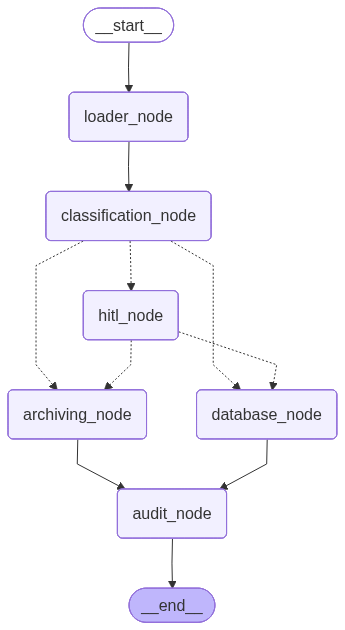

Graph rendered above.


In [113]:
try:
    from IPython.display import Image, display
    img = graph.get_graph().draw_mermaid_png()
    display(Image(img))
    print("Graph rendered above.")
except Exception as e:
    print(f"PNG unavailable ({e}), Mermaid text:")
    print(graph.get_graph().draw_mermaid())


## Section 17 · Processing Functions

- `process_document(pdf_path)` — run one PDF through the full pipeline
- `process_all_documents(pdf_dir)` — batch all PDFs in a directory


In [114]:
def process_document(pdf_path: str) -> DocumentState:
    """Run a single PDF through the complete 6-agent pipeline."""
    thread_id = str(uuid.uuid4())
    config    = {"configurable": {"thread_id": thread_id}}

    initial: DocumentState = {
        "pdf_path":         str(pdf_path),
        "doc_name":         "",
        "date_processed":   "",
        "raw_text":         None,
        "classification":   None,
        "confidence":       None,
        "reasoning":        None,
        "llm_retry_count":  0,
        "hitl_retry_count": 0,
        "human_decision":   None,
        "db_record_id":     None,
        "archive_written":  False,
        "audit_trail":      [],
        "error":            None,
    }

    print(f"\n{'='*58}")
    print(f"  Processing: {Path(pdf_path).name}")
    print(f"{'='*58}")

    final = graph.invoke(initial, config=config)

    cl    = final.get("classification")
    cf    = final.get("confidence") or 0
    label = cl.value if isinstance(cl, Classification) else str(cl)
    print(f"  Result    : {label}  (confidence {cf:.2f})")
    print(f"  Reasoning : {(final.get('reasoning') or '')[:100]}")
    if final.get("error"):
        print(f"  Error     : {final['error']}")

    return final


def process_all_documents(pdf_dir=None) -> list:
    """Batch-process all PDFs in a directory."""
    search_dir = Path(pdf_dir) if pdf_dir else PDF_DIR
    pdf_files  = sorted(search_dir.glob("*.pdf"))

    if not pdf_files:
        print(f"No PDFs found in {search_dir}")
        return []

    print(f"Batch processing {len(pdf_files)} document(s) from {search_dir}")
    results = []
    for pdf_file in pdf_files:
        results.append(process_document(str(pdf_file)))
    return results

print("process_document() and process_all_documents() ready.")


process_document() and process_all_documents() ready.


## Section 18 · Inspection Utilities

Helpers to inspect all outputs after processing.


In [115]:
def show_database(n=20):
    print("\n  SQLite -- cease_documents")
    print("  " + "-"*86)
    try:
        conn = sqlite3.connect(str(DB_PATH))
        rows = conn.execute(
            "SELECT id, doc_name, date_processed, classification, confidence, reasoning "
            "FROM cease_documents ORDER BY id DESC LIMIT ?", (n,)
        ).fetchall()
        conn.close()
        if not rows:
            print("  (no records)")
            return
        print(f"  {'ID':<5} {'Document':<28} {'Date':<22} {'Label':<12} {'Conf':<6} Reasoning")
        print(f"  {'-'*5} {'-'*28} {'-'*22} {'-'*12} {'-'*6} {'-'*25}")
        for id_, name, date, label, conf, reason in rows:
            print(f"  {id_:<5} {name:<28} {date:<22} {label:<12} {conf:<6.2f} {(reason or '')[:45]}")
    except Exception as e:
        print(f"  Error: {e}")


def show_archive(n=20):
    print("\n  JSONL Archive")
    print("  " + "-"*70)
    try:
        if not ARCHIVE_PATH.exists():
            print("  (archive not yet created)")
            return
        with open(str(ARCHIVE_PATH), encoding="utf-8") as f:
            lines = f.readlines()
        if not lines:
            print("  (empty)")
            return
        for line in lines[-n:]:
            r = json.loads(line)
            print(f"  {r.get('doc_name','?')} | {r.get('date_processed','?')} "
                  f"| {r.get('classification','?')} | conf={r.get('confidence',0):.2f}")
    except Exception as e:
        print(f"  Error: {e}")


def show_audit_log(n=50):
    print("\n  Audit Log (last entries)")
    print("  " + "-"*70)
    try:
        if not AUDIT_LOG_PATH.exists():
            print("  (log not yet created)")
            return
        with open(str(AUDIT_LOG_PATH), encoding="utf-8") as f:
            lines = f.readlines()
        for line in lines[-n:]:
            print(" ", line.rstrip())
    except Exception as e:
        print(f"  Error: {e}")


def print_summary(results: list):
    print("\n" + "="*68)
    print("  BATCH SUMMARY")
    print("="*68)
    if not results:
        print("  No results.")
        return
    counts = {c: 0 for c in Classification}
    print(f"  {'Document':<28} {'Classification':<14} {'Conf':<8} DB_ID")
    print(f"  {'-'*28} {'-'*14} {'-'*8} {'-'*6}")
    for r in results:
        cl    = r.get("classification")
        label = cl.value if isinstance(cl, Classification) else str(cl)
        conf  = r.get("confidence") or 0
        db_id = r.get("db_record_id") or "-"
        print(f"  {r.get('doc_name','?'):<28} {label:<14} {conf:<8.2f} {db_id}")
        if isinstance(cl, Classification):
            counts[cl] += 1
    print(f"\n  Cease={counts[Classification.CEASE]} | "
          f"Uncertain={counts[Classification.UNCERTAIN]} | "
          f"Irrelevant={counts[Classification.IRRELEVANT]}")

print("Inspection utilities defined.")


Inspection utilities defined.


## Section 19 · Time Travel & Checkpoint History

`MemorySaver` stores the full `DocumentState` after every node.
Use `inspect_checkpoint_history()` to replay a document's execution trace step by step.

> LangSmith provides the same view visually at smith.langchain.com.


In [116]:
def inspect_checkpoint_history(thread_id: str):
    config = {"configurable": {"thread_id": thread_id}}
    print(f"\n  Checkpoint history for thread {thread_id[:20]}...")
    print("  " + "-"*66)
    try:
        history = list(graph.get_state_history(config))
        print(f"  Total checkpoints: {len(history)}")
        for i, snap in enumerate(reversed(history)):
            step   = snap.metadata.get("step", i)
            source = snap.metadata.get("source", "?")
            cl     = snap.values.get("classification")
            label  = cl.value if isinstance(cl, Classification) else str(cl)
            name   = snap.values.get("doc_name", "?")
            print(f"  step {step:<3} | {source:<25} | {name:<28} | {label}")
    except Exception as e:
        print(f"  Error: {e}")

print("inspect_checkpoint_history() defined.")


inspect_checkpoint_history() defined.


## Section 20 · Bonus — FAISS Semantic Search

Build a local FAISS vector index over processed Cease documents using
**HuggingFace sentence-transformers** (runs locally, no API key required).

Use case: *"Find all Cease requests similar to this new complaint"*


In [117]:
FAISS_AVAILABLE = False

try:
    from langchain_community.vectorstores import FAISS
    from langchain_community.embeddings import HuggingFaceEmbeddings
    from langchain_core.documents import Document as LCDocument

    hf_embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )
    FAISS_AVAILABLE = True
    print("FAISS + HuggingFace embeddings ready (local, no API key).")

except ImportError as e:
    print(f"FAISS not available: {e}")


def build_faiss_index(results: list):
    if not FAISS_AVAILABLE:
        return None
    cease_docs = [
        r for r in results
        if r.get("classification") == Classification.CEASE and r.get("raw_text")
    ]
    if not cease_docs:
        print("No Cease documents to index.")
        return None
    lc_docs = [
        LCDocument(
            page_content=r["raw_text"],
            metadata={"doc_name": r.get("doc_name", ""), "db_id": r.get("db_record_id")}
        )
        for r in cease_docs
    ]
    print(f"  Indexing {len(lc_docs)} Cease document(s)...")
    vs = FAISS.from_documents(lc_docs, hf_embeddings)
    vs.save_local(str(FAISS_INDEX))
    print(f"  FAISS index saved to {FAISS_INDEX}")
    return vs


def semantic_search(query: str, vectorstore, k: int = 3):
    if not vectorstore:
        print("No FAISS index available.")
        return
    print(f"\n  Semantic search: '{query}'")
    for doc, score in vectorstore.similarity_search_with_score(query, k=k):
        snippet = doc.page_content[:180].replace("\n", " ")
        print(f"  score={score:.4f} | {doc.metadata.get('doc_name','?')}")
        print(f"  {snippet}...\n")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FAISS + HuggingFace embeddings ready (local, no API key).


## Section 21 · Reset Utility

Wipe all generated outputs (database, archive, audit log, FAISS index) and start fresh.


In [118]:
def reset_all_data(confirm: bool = False):
    if not confirm:
        print("Pass confirm=True to execute reset.")
        return
    import shutil
    for path in [DB_PATH, ARCHIVE_PATH, AUDIT_LOG_PATH]:
        if path.exists():
            path.unlink()
            print(f"  Deleted: {path}")
    if FAISS_INDEX.exists():
        shutil.rmtree(str(FAISS_INDEX))
        print(f"  Deleted FAISS index: {FAISS_INDEX}")
    init_database()
    print("Reset complete.")

# reset_all_data(confirm=True)
print("reset_all_data() defined. Uncomment the line above to run.")


reset_all_data() defined. Uncomment the line above to run.


## Section 22 · End-to-End Demo

Run this single cell to execute the complete pipeline on all sample PDFs.

Observability dashboards open in parallel:
- **LangSmith** — smith.langchain.com → project `cease-desist-multiagent`
- **Arize** — app.arize.com → your space


In [119]:
print("Cease & Desist Multi-Agent Pipeline -- Starting")
print("=" * 58)
print(f"  LLM         : Groq / {GROQ_MODEL}")
print(f"  LangSmith   : {'ON' if os.environ.get('LANGCHAIN_TRACING_V2') == 'true' else 'OFF'}")
print(f"  Arize       : {'ON' if ARIZE_ENABLED else 'OFF'}")
print("=" * 58)

results = process_all_documents()

print_summary(results)
show_database()
show_archive()
show_audit_log(n=50)

if FAISS_AVAILABLE:
    print("\n" + "="*58)
    print("  FAISS Semantic Search Demo")
    print("="*58)
    vs = build_faiss_index(results)
    if vs:
        semantic_search("stop sending me marketing emails", vs)
        semantic_search("invoice payment overdue", vs)

print("\nPipeline complete.")
if os.environ.get("LANGCHAIN_TRACING_V2") == "true":
    print("  View LangSmith traces : https://smith.langchain.com")
if ARIZE_ENABLED:
    print("  View Arize dashboard  : https://app.arize.com")


Cease & Desist Multi-Agent Pipeline -- Starting
  LLM         : Groq / llama-3.3-70b-versatile
  LangSmith   : ON
  Arize       : ON
Batch processing 19 document(s) from /content/Sample Docs

  Processing: LOA2.pdf
  Result    : Cease  (confidence 0.98)
  Reasoning : The document contains a clear and explicit demand to cease and desist all communications regarding t

  Processing: LOA3.pdf
  Result    : Cease  (confidence 0.98)
  Reasoning : The document contains a clear and explicit demand to cease and desist all communications regarding t

  Processing: LOA4.pdf
  Result    : Cease  (confidence 0.98)
  Reasoning : The document contains a clear and explicit demand to cease and desist all communications regarding t

  Processing: LOA5.pdf
  Result    : Cease  (confidence 0.98)
  Reasoning : The document contains a clear and explicit demand to cease and desist all communications regarding t

  Processing: LOA6.pdf
  Result    : Cease  (confidence 0.99)
  Reasoning : The document contain

## Section 23 · Architecture Summary & Production Checklist

### Four Observability Layers

| Layer | Tool | What it tracks |
|-------|------|---------------|
| LLM call tracing | **LangSmith** | Inputs, outputs, latency, cost per call |
| Model monitoring | **Arize Phoenix** | Classification drift, confidence distribution, anomalies |
| Compliance trail | **Audit log** | Every agent action with timestamp |
| State snapshots | **LangGraph MemorySaver** | Full state after every node, supports time-travel |

### Key Design Decisions

| Decision | Rationale |
|----------|-----------|
| Groq Llama 3.3 70B | Free, fast, supports structured output natively |
| Confidence gate 0.70 | Prevents low-quality classifications reaching production |
| Pydantic structured output | Eliminates brittle string parsing of LLM responses |
| Immutable state pattern | Each agent returns new dict -- no hidden side effects |
| JSONL archiving | Streamable, appendable, no schema migration needed |

